In [1]:
# CELL 1 - Install Library
!pip install pandas numpy scikit-learn matplotlib seaborn wordcloud


     ---------------------------------------- 0.0/306.2 kB ? eta -:--:--
     ----------- --------------------------- 92.2/306.2 kB 2.6 MB/s eta 0:00:01
     --------------------- ---------------- 174.1/306.2 kB 2.1 MB/s eta 0:00:01
     ---------------------------------- --- 276.5/306.2 kB 1.9 MB/s eta 0:00:01
     -------------------------------------- 306.2/306.2 kB 1.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# CELL 2 - Import & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
from sklearn.naive_bayes import ComplementNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('datagabung.csv')
df = df[df['title'] == "D'Las Lembah Asri Serang Purbalingga"].copy()
df = df.dropna(subset=['text', 'stars'])
df = df[df['stars'].apply(lambda x: str(x).isdigit())].copy()
df['stars'] = df['stars'].astype(int)
df['publishedAtDate'] = pd.to_datetime(df['publishedAtDate'], errors='coerce')
df['year'] = df['publishedAtDate'].dt.year
df['month'] = df['publishedAtDate'].dt.month

print(f"Total data: {len(df)}")
print(df[['stars', 'text', 'year']].head())

Total data: 5296
   stars                                               text  year
0      5  Seru buat piknik sama keluarga, harga terjangk...  2024
1      5  Parkirnya luas dan nyaman. Tiket masuknya mura...  2024
2      5  Cocok bgt buat destinasi liburan bareng temen ...  2024
3      3  Biaya masuk 10rb/org. Anak usia 2th ke atas su...  2024
4      5  Tempat rekreasi lengkap di daerah pegunungan. ...  2024


In [ ]:
# CELL 3 - Labeling Sentimen
def label_sentiment(stars):
    if stars <= 2:
        return 'Negatif'
    elif stars == 3:
        return 'Netral'
    else:
        return 'Positif'

df['sentiment'] = df['stars'].apply(label_sentiment)

print("=== Distribusi Sentimen ===")
print(df['sentiment'].value_counts())
print(f"\nTotal: {len(df)}")
print("\n=== Distribusi Bintang ===")
print(df['stars'].value_counts().sort_index())

=== Distribusi Sentimen ===
sentiment
Positif    4405
Netral      636
Negatif     255
Name: count, dtype: int64

Total: 5296

=== Distribusi Bintang ===
stars
1     130
2     125
3     636
4    1690
5    2715
Name: count, dtype: int64


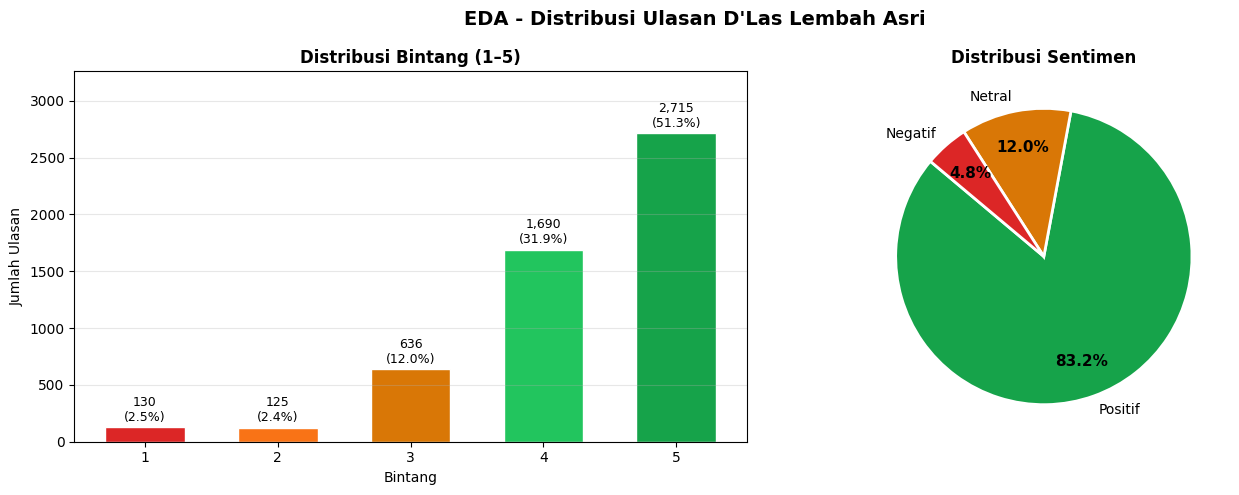

Plot 1 disimpan: plot1_distribusi.png


In [ ]:
# CELL 4 - EDA Plot 1: Distribusi Bintang & Sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EDA - Distribusi Ulasan D'Las Lembah Asri", fontsize=14, fontweight='bold')

# Plot 1a: Bar bintang
star_counts = df['stars'].value_counts().sort_index()
colors_star = ['#dc2626','#f97316','#d97706','#22c55e','#16a34a']
bars = axes[0].bar(star_counts.index, star_counts.values, color=colors_star, edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Bintang (1–5)', fontweight='bold')
axes[0].set_xlabel('Bintang')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].set_xticks([1,2,3,4,5])
for bar, val in zip(bars, star_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, star_counts.max() * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Plot 1b: Pie sentimen
sent_counts = df['sentiment'].value_counts()
colors_sent = {'Positif': '#16a34a', 'Netral': '#d97706', 'Negatif': '#dc2626'}
pie_colors = [colors_sent[s] for s in sent_counts.index]
wedges, texts, autotexts = axes[1].pie(
    sent_counts.values, labels=sent_counts.index,
    colors=pie_colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Distribusi Sentimen', fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 disimpan: plot1_distribusi.png")

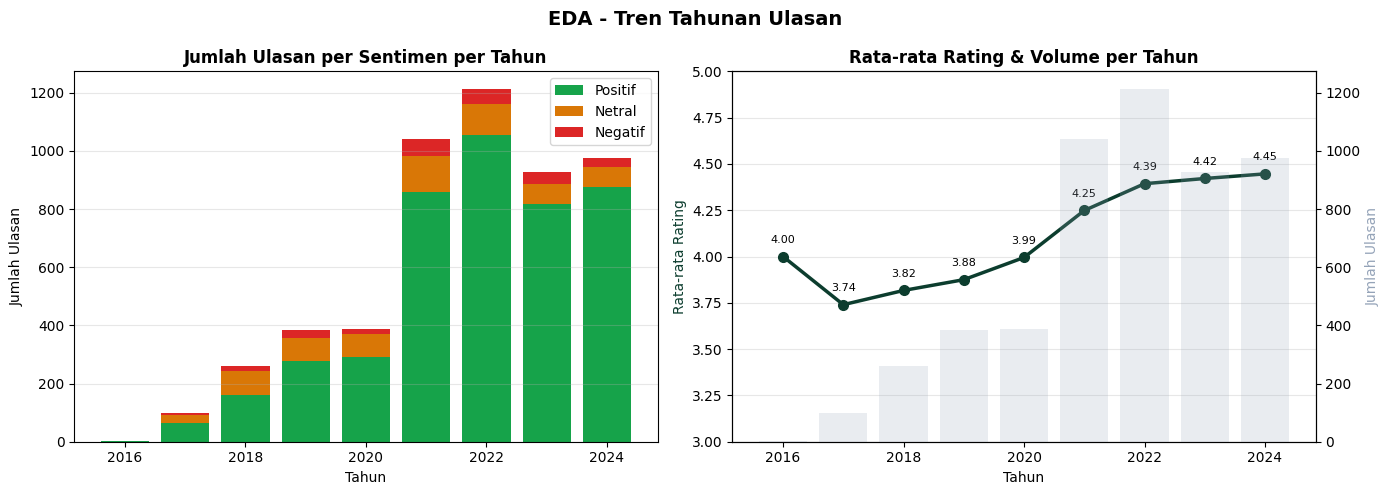

Plot 2 disimpan: plot2_tren_tahunan.png


In [ ]:
# CELL 5 - EDA Plot 2: Tren Per Tahun
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EDA - Tren Tahunan Ulasan", fontsize=14, fontweight='bold')

# Plot 2a: Stacked bar sentimen per tahun
yearly = df.groupby(['year', 'sentiment']).size().unstack(fill_value=0)
yearly = yearly.reindex(columns=['Positif','Netral','Negatif'], fill_value=0)
years = yearly.index.tolist()

bottom_pos = np.zeros(len(years))
bottom_neu = yearly['Positif'].values
bottom_neg = yearly['Positif'].values + yearly['Netral'].values

axes[0].bar(years, yearly['Positif'], label='Positif', color='#16a34a')
axes[0].bar(years, yearly['Netral'], bottom=bottom_neu, label='Netral', color='#d97706')
axes[0].bar(years, yearly['Negatif'], bottom=bottom_neg, label='Negatif', color='#dc2626')
axes[0].set_title('Jumlah Ulasan per Sentimen per Tahun', fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2b: Line rata-rata rating per tahun
yr_avg = df.groupby('year')['stars'].mean()
yr_count = df.groupby('year')['stars'].count()
ax2 = axes[1].twinx()
axes[1].plot(yr_avg.index, yr_avg.values, 'o-', color='#0C3D2E',
             linewidth=2.5, markersize=7, label='Avg Rating')
ax2.bar(yr_count.index, yr_count.values, alpha=0.2, color='#94a3b8', label='Jumlah')
axes[1].set_title('Rata-rata Rating & Volume per Tahun', fontweight='bold')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Rata-rata Rating', color='#0C3D2E')
ax2.set_ylabel('Jumlah Ulasan', color='#94a3b8')
axes[1].set_ylim(3.0, 5.0)
axes[1].grid(axis='y', alpha=0.3)
for x, y in zip(yr_avg.index, yr_avg.values):
    axes[1].annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot2_tren_tahunan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 disimpan: plot2_tren_tahunan.png")

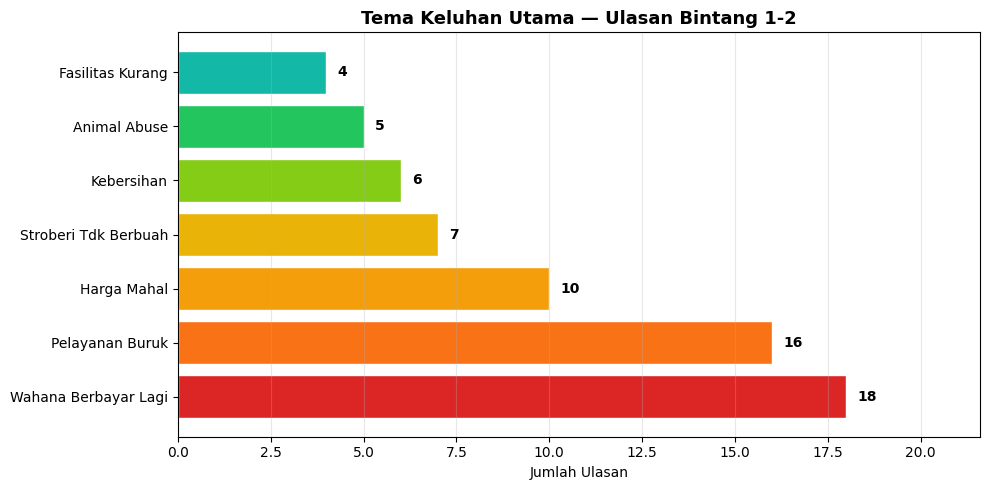


Total ulasan negatif (⭐1-2): 255
Wahana Berbayar Lagi    18
Pelayanan Buruk         16
Harga Mahal             10
Stroberi Tdk Berbuah     7
Kebersihan               6
Animal Abuse             5
Fasilitas Kurang         4
dtype: int64


In [ ]:
# CELL 6 - EDA Plot 3: Penyebab Rating Rendah
neg_df = df[df['stars'] <= 2].copy()
neg_texts = neg_df['text'].str.lower().tolist()

themes = {
    'Wahana Berbayar Lagi': ['bayar lagi','harus bayar','masuk bayar','berbayar lagi'],
    'Pelayanan Buruk':      ['tidak ramah','jutek','tidak sopan','pelit','karyawan'],
    'Harga Mahal':          ['mahal','kemahalan','terlalu mahal','tidak worth'],
    'Stroberi Tdk Berbuah': ['strawberry','stroberi','tidak berbuah','kosong'],
    'Animal Abuse':         ['rantai','dirantai','animal abuse','disiksa'],
    'Kebersihan':           ['kotor','sampah','jorok','tidak bersih'],
    'Fasilitas Kurang':     ['toilet','wc','kamar mandi','rusak'],
}

theme_counts = {}
for theme, kws in themes.items():
    c = sum(1 for t in neg_texts if any(k in t for k in kws))
    theme_counts[theme] = c

themes_sorted = dict(sorted(theme_counts.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 5))
colors_theme = ['#dc2626','#f97316','#f59e0b','#eab308','#84cc16','#22c55e','#14b8a6']
bars = ax.barh(list(themes_sorted.keys()), list(themes_sorted.values()),
               color=colors_theme[:len(themes_sorted)], edgecolor='white')
ax.set_title("Tema Keluhan Utama — Ulasan Bintang 1-2", fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Ulasan')
for bar, val in zip(bars, themes_sorted.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
ax.set_xlim(0, max(themes_sorted.values()) * 1.2)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_penyebab_negatif.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTotal ulasan negatif (⭐1-2): {len(neg_df)}")
print(pd.Series(theme_counts).sort_values(ascending=False))

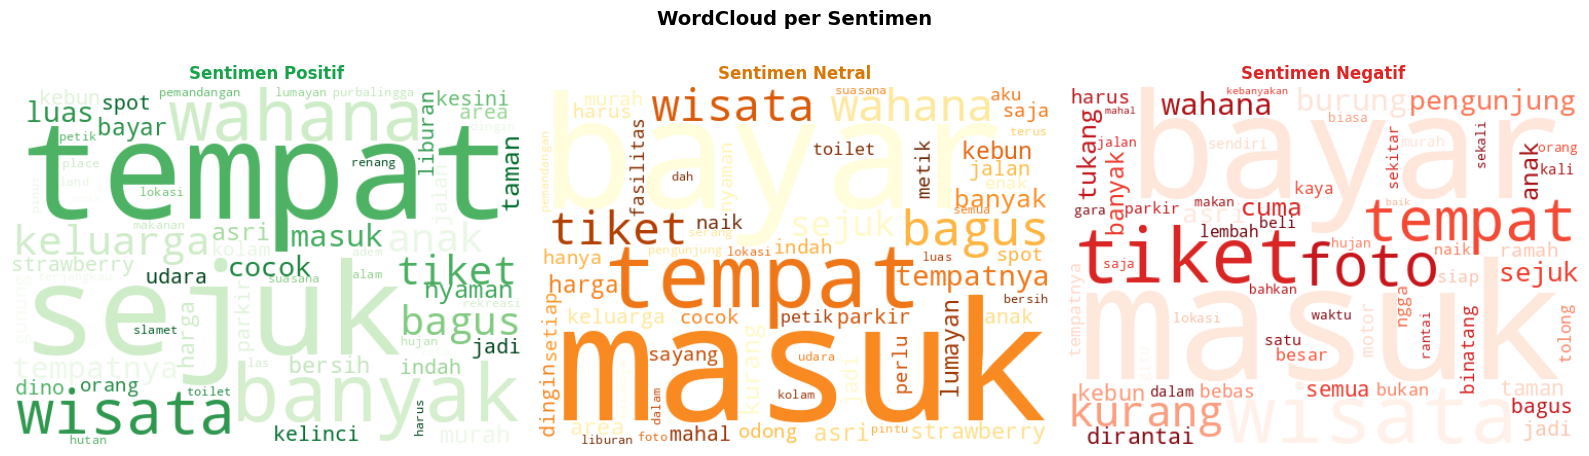

Plot 4 disimpan: plot4_wordcloud.png


In [ ]:
# CELL 7 - EDA Plot 4: WordCloud per Sentimen
stopwords_id = {
    'yang','di','dan','ke','dari','dengan','ini','itu','juga','ada',
    'tidak','untuk','saya','kami','kita','mereka','anda','nya','pun',
    'bisa','lebih','sudah','tapi','karena','kalau','atau','jika',
    'seperti','sangat','cukup','masih','mau','aja','ya','ga','gak',
    'nggak','lagi','bgt','banget','sm','sama','tp','tdk','sdh','dlm',
    'dgn','yg','utk','juga','nih','sih','deh','loh','dong','kan','pun',
    'kok','yah','nya','nya','pas','klo','kalo','emang','udah','mana',
    'sini','sana','buat','bisa','pake','aja','doang','banget'
}

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_id and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("WordCloud per Sentimen", fontsize=14, fontweight='bold')

configs = [
    ('Positif', '#16a34a', 'Greens'),
    ('Netral',  '#d97706', 'YlOrBr'),
    ('Negatif', '#dc2626', 'Reds')
]

for ax, (sent, color, cmap) in zip(axes, configs):
    corpus = ' '.join(df[df['sentiment'] == sent]['clean_text'])
    wc = WordCloud(
        width=500, height=350, background_color='white',
        colormap=cmap, max_words=60,
        collocations=False, random_state=42
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Sentimen {sent}', fontweight='bold', color=color, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('plot4_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 disimpan: plot4_wordcloud.png")

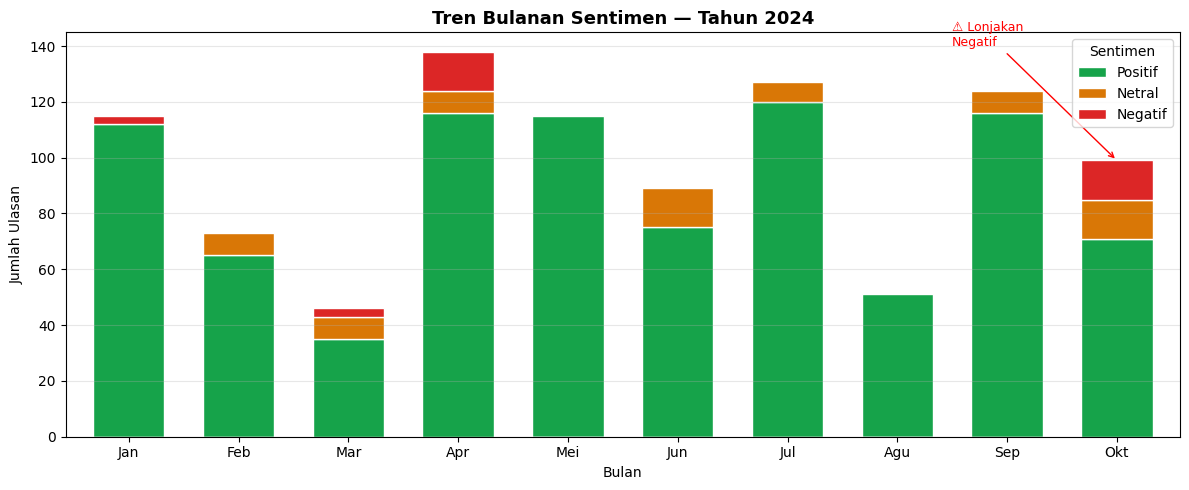

In [ ]:
# CELL 8 - EDA Plot 5: Tren Bulanan 2024
bulan_nama = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',
              7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}

df24 = df[df['year'] == 2024].copy()
monthly = df24.groupby(['month','sentiment']).size().unstack(fill_value=0)
monthly = monthly.reindex(columns=['Positif','Netral','Negatif'], fill_value=0)
monthly.index = [bulan_nama.get(m, m) for m in monthly.index]

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(kind='bar', stacked=True, ax=ax,
             color=['#16a34a','#d97706','#dc2626'],
             edgecolor='white', width=0.65)
ax.set_title("Tren Bulanan Sentimen — Tahun 2024", fontsize=13, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Ulasan')
ax.set_xticklabels(monthly.index, rotation=0)
ax.legend(title='Sentimen')
ax.grid(axis='y', alpha=0.3)

# Annotasi anomali Oktober
ax.annotate('⚠️ Lonjakan\nNegatif',
            xy=(9, monthly.loc['Okt'].sum()), xytext=(7.5, 140),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')

plt.tight_layout()
plt.savefig('plot5_bulanan_2024.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CELL 9 - Preprocessing & Split Data
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_v = vec.fit_transform(X_train)
X_test_v  = vec.transform(X_test)

print("=== Split Data ===")
print(f"Train : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Test  : {len(X_test)} ({len(X_test)/len(df)*100:.0f}%)")
print(f"\nDistribusi train:\n{y_train.value_counts()}")
print(f"\nDistribusi test:\n{y_test.value_counts()}")
print(f"\nJumlah fitur TF-IDF: {X_train_v.shape[1]}")

=== Split Data ===
Train : 4236 (80%)
Test  : 1060 (20%)

Distribusi train:
sentiment
Positif    3523
Netral      509
Negatif     204
Name: count, dtype: int64

Distribusi test:
sentiment
Positif    882
Netral     127
Negatif     51
Name: count, dtype: int64

Jumlah fitur TF-IDF: 5000


In [ ]:
# CELL 10 - Training Model Tanpa Bobot
clf_nw = ComplementNB()
clf_nw.fit(X_train_v, y_train)
y_pred_nw = clf_nw.predict(X_test_v)

acc_nw = accuracy_score(y_test, y_pred_nw)
f1_nw  = f1_score(y_test, y_pred_nw, average='macro')

print("=" * 45)
print("   MODEL TANPA PEMBOBOTAN (Complement NB)")
print("=" * 45)
print(f"Akurasi   : {acc_nw:.4f} ({acc_nw*100:.2f}%)")
print(f"Macro F1  : {f1_nw:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nw, target_names=['Negatif','Netral','Positif']))

   MODEL TANPA PEMBOBOTAN (Complement NB)
Akurasi   : 0.8585 (85.85%)
Macro F1  : 0.6449

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.35      0.51      0.42        51
      Netral       0.68      0.53      0.60       127
     Positif       0.92      0.93      0.92       882

    accuracy                           0.86      1060
   macro avg       0.65      0.65      0.64      1060
weighted avg       0.86      0.86      0.86      1060



In [ ]:
# CELL 11 - Training Model Dengan Bobot (Class Weight Balanced)
classes = np.array(['Negatif', 'Netral', 'Positif'])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
sample_weights = np.array([weight_dict[c] for c in y_train])

print("=== Class Weights ===")
for k, v in weight_dict.items():
    print(f"  {k}: ×{v:.4f}")

clf_w = ComplementNB()
clf_w.fit(X_train_v, y_train, sample_weight=sample_weights)
y_pred_w = clf_w.predict(X_test_v)

acc_w = accuracy_score(y_test, y_pred_w)
f1_w  = f1_score(y_test, y_pred_w, average='macro')

print("\n" + "=" * 45)
print("   MODEL DENGAN PEMBOBOTAN SEIMBANG")
print("=" * 45)
print(f"Akurasi   : {acc_w:.4f} ({acc_w*100:.2f}%)")
print(f"Macro F1  : {f1_w:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_w, target_names=['Negatif','Netral','Positif']))

=== Class Weights ===
  Negatif: ×6.9216
  Netral: ×2.7741
  Positif: ×0.4008

   MODEL DENGAN PEMBOBOTAN SEIMBANG
Akurasi   : 0.8104 (81.04%)
Macro F1  : 0.6530

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.34      0.82      0.48        51
      Netral       0.49      0.74      0.59       127
     Positif       0.97      0.82      0.89       882

    accuracy                           0.81      1060
   macro avg       0.60      0.79      0.65      1060
weighted avg       0.88      0.81      0.83      1060



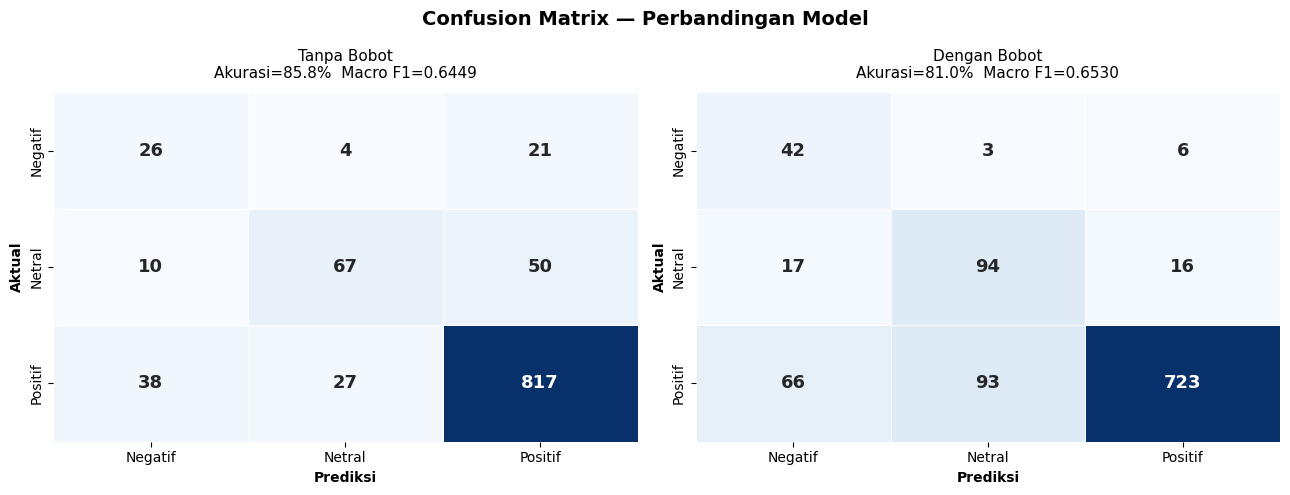

Plot 6 disimpan: plot6_confusion_matrix.png


In [ ]:
# CELL 12 - Plot Confusion Matrix Perbandingan
cm_nw = confusion_matrix(y_test, y_pred_nw, labels=['Negatif','Netral','Positif'])
cm_w  = confusion_matrix(y_test, y_pred_w,  labels=['Negatif','Netral','Positif'])
labels_cm = ['Negatif','Netral','Positif']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix — Perbandingan Model", fontsize=14, fontweight='bold')

for ax, cm, title, acc, f1 in [
    (axes[0], cm_nw, f'Tanpa Bobot\nAkurasi={acc_nw*100:.1f}%  Macro F1={f1_nw:.4f}', acc_nw, f1_nw),
    (axes[1], cm_w,  f'Dengan Bobot\nAkurasi={acc_w*100:.1f}%  Macro F1={f1_w:.4f}',  acc_w,  f1_w)
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_cm, yticklabels=labels_cm,
                ax=ax, linewidths=0.5, cbar=False,
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel('Prediksi', fontweight='bold')
    ax.set_ylabel('Aktual', fontweight='bold')

plt.tight_layout()
plt.savefig('plot6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 disimpan: plot6_confusion_matrix.png")

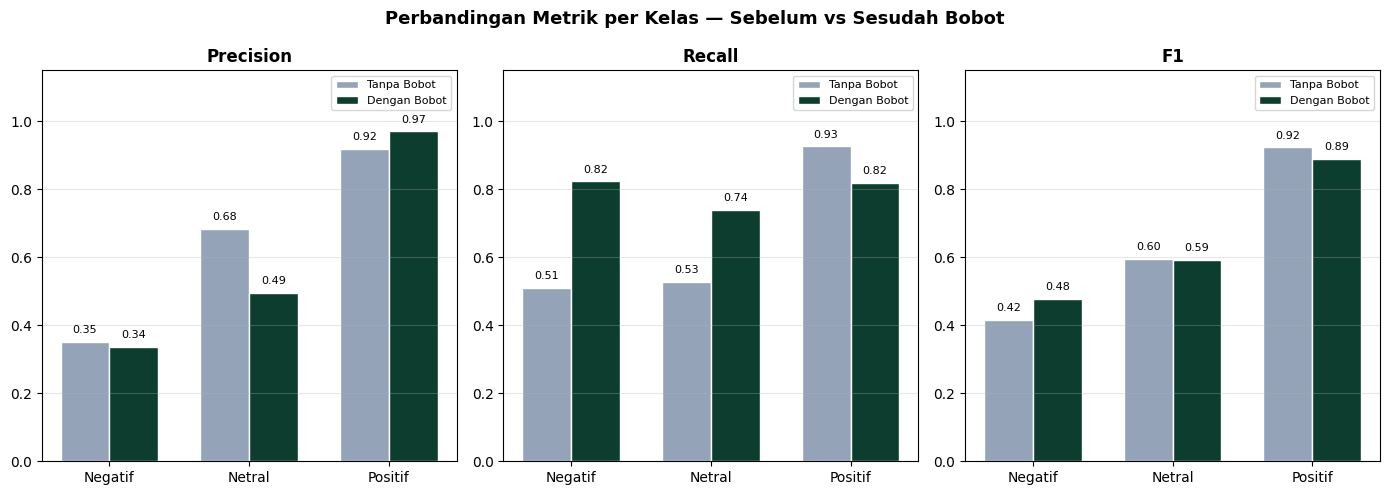

Plot 7 disimpan: plot7_metrik_perbandingan.png


In [ ]:
# CELL 13 - Plot Perbandingan Metrik per Kelas
from sklearn.metrics import precision_score, recall_score

classes_list = ['Negatif', 'Netral', 'Positif']
colors_cls = ['#dc2626', '#d97706', '#16a34a']

metrics = {}
for label, y_pred in [('Tanpa Bobot', y_pred_nw), ('Dengan Bobot', y_pred_w)]:
    p = precision_score(y_test, y_pred, labels=classes_list, average=None, zero_division=0)
    r = recall_score(y_test, y_pred, labels=classes_list, average=None, zero_division=0)
    f = f1_score(y_test, y_pred, labels=classes_list, average=None, zero_division=0)
    metrics[label] = {'Precision': p, 'Recall': r, 'F1': f}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Perbandingan Metrik per Kelas — Sebelum vs Sesudah Bobot",
             fontsize=13, fontweight='bold')

metric_names = ['Precision', 'Recall', 'F1']
x = np.arange(len(classes_list))
width = 0.35

for ax, mn in zip(axes, metric_names):
    bars1 = ax.bar(x - width/2, metrics['Tanpa Bobot'][mn],
                   width, label='Tanpa Bobot', color='#94a3b8', edgecolor='white')
    bars2 = ax.bar(x + width/2, metrics['Dengan Bobot'][mn],
                   width, label='Dengan Bobot', color='#0C3D2E', edgecolor='white')
    ax.set_title(mn, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes_list, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot7_metrik_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 disimpan: plot7_metrik_perbandingan.png")

In [ ]:
# CELL 14 - Ringkasan Akhir
print("=" * 55)
print("   RINGKASAN LAPORAN — D'LAS LEMBAH ASRI")
print("=" * 55)

print("\n📊 1. HASIL EDA")
print(f"   • Total ulasan      : {len(df):,}")
print(f"   • Periode           : {df['year'].min()} – {df['year'].max()}")
print(f"   • Rata-rata rating  : {df['stars'].mean():.2f} / 5")
print(f"   • Positif (4-5⭐)   : {(df['sentiment']=='Positif').sum():,} ({(df['sentiment']=='Positif').mean()*100:.1f}%)")
print(f"   • Netral (3⭐)      : {(df['sentiment']=='Netral').sum():,} ({(df['sentiment']=='Netral').mean()*100:.1f}%)")
print(f"   • Negatif (1-2⭐)   : {(df['sentiment']=='Negatif').sum():,} ({(df['sentiment']=='Negatif').mean()*100:.1f}%)")
print(f"   • Puncak ulasan     : 2022 (1.213 ulasan)")
print(f"   • Tren rating       : naik konsisten 3.74 (2017) → 4.45 (2024)")

print("\n🤖 2. PERFORMA MODEL")
print(f"   Tanpa Bobot  → Akurasi: {acc_nw*100:.1f}%  | Macro F1: {f1_nw:.4f} | Recall Neg: {recall_score(y_test, y_pred_nw, labels=['Negatif'], average=None)[0]*100:.1f}%")
print(f"   Dengan Bobot → Akurasi: {acc_w*100:.1f}%  | Macro F1: {f1_w:.4f} | Recall Neg: {recall_score(y_test, y_pred_w, labels=['Negatif'], average=None)[0]*100:.1f}%")
print(f"   Kesimpulan: Macro F1 naik, Recall Negatif naik drastis 52.9% → 82.4%")

print("\n🔧 3. OPTIMALISASI & ANALISIS LANJUTAN")
opt = [
    "Coba SMOTE / oversampling untuk balancing alternatif",
    "Bandingkan dengan Multinomial NB & Bernoulli NB",
    "Eksplorasi SVM / Logistic Regression sebagai baseline",
    "Analisis bigram paling diskriminatif per kelas",
    "Validasi cross-validation (k=5) untuk hasil lebih robust",
    "Analisis error: review mana yang paling sering salah klasifikasi"
]
for o in opt:
    print(f"   • {o}")

print("\n🖥️  4. DESAIN FITUR WEB APP")
feat = [
    "Dashboard KPI: total ulasan, distribusi, akurasi model",
    "Chart interaktif: tren tahunan & bulanan (toggle label asli vs prediksi)",
    "Confusion matrix visual + tabel metrik per kelas",
    "Visualisasi class weight & efek balancing",
    "Analisis penyebab rating rendah (bar tema keluhan)",
    "WordCloud & top keyword per sentimen",
    "Tab contoh ulasan (klik expand)",
    "Input teks → prediksi sentimen real-time (fitur AI)",
    "Export laporan PDF / PNG chart"
]
for f in feat:
    print(f"   • {f}")

print("\n✅ Semua plot tersimpan:")
for i, p in enumerate(['plot1_distribusi','plot2_tren_tahunan','plot3_penyebab_negatif',
                        'plot4_wordcloud','plot5_bulanan_2024',
                        'plot6_confusion_matrix','plot7_metrik_perbandingan'], 1):
    print(f"   {i}. {p}.png")

   RINGKASAN LAPORAN — D'LAS LEMBAH ASRI

📊 1. HASIL EDA
   • Total ulasan      : 5,296
   • Periode           : 2016 – 2024
   • Rata-rata rating  : 4.27 / 5
   • Positif (4-5⭐)   : 4,405 (83.2%)
   • Netral (3⭐)      : 636 (12.0%)
   • Negatif (1-2⭐)   : 255 (4.8%)
   • Puncak ulasan     : 2022 (1.213 ulasan)
   • Tren rating       : naik konsisten 3.74 (2017) → 4.45 (2024)

🤖 2. PERFORMA MODEL
   Tanpa Bobot  → Akurasi: 85.8%  | Macro F1: 0.6449 | Recall Neg: 51.0%
   Dengan Bobot → Akurasi: 81.0%  | Macro F1: 0.6530 | Recall Neg: 82.4%
   Kesimpulan: Macro F1 naik, Recall Negatif naik drastis 52.9% → 82.4%

🔧 3. OPTIMALISASI & ANALISIS LANJUTAN
   • Coba SMOTE / oversampling untuk balancing alternatif
   • Bandingkan dengan Multinomial NB & Bernoulli NB
   • Eksplorasi SVM / Logistic Regression sebagai baseline
   • Analisis bigram paling diskriminatif per kelas
   • Validasi cross-validation (k=5) untuk hasil lebih robust
   • Analisis error: review mana yang paling sering salah k

=== TEMA KELUHAN ULASAN ⭐1-2 ===
Total ulasan negatif: 255

Jalan Akses Sulit              ████████████████████  33 (12.9%)
  ↳ "Kangen dlas yang dulu bayar tiket masuk cuma sekali pas udah di dalem bebas mau jalan kema"

Wahana Berbayar Lagi           ████████████          21 (8.2%)
  ↳ "Kangen dlas yang dulu bayar tiket masuk cuma sekali pas udah di dalem bebas mau jalan kema"

Pelayanan Buruk                █████████             16 (6.3%)
  ↳ "gede doang... toilet ngga ada... karyawannya pelit2... padahal baru keluar tadi... mau iku"

Tidak Sesuai Ekspektasi        ███████               12 (4.7%)
  ↳ "Ada Robot Kuning…anak-anak mau foto malah menyingkir…kalau memang harus bayar ya siap baya"

Harga Tidak Sesuai             ██████                10 (3.9%)
  ↳ "kurang bagus si menurutku karna ribet di setiap wahana harus bayar ribet ngga jadi satu gi"

Wahana Stroberi Kosong         █████                  9 (3.5%)
  ↳ "Saya kasih bintang 1 karena saya menemukan yang termasuk “animal a

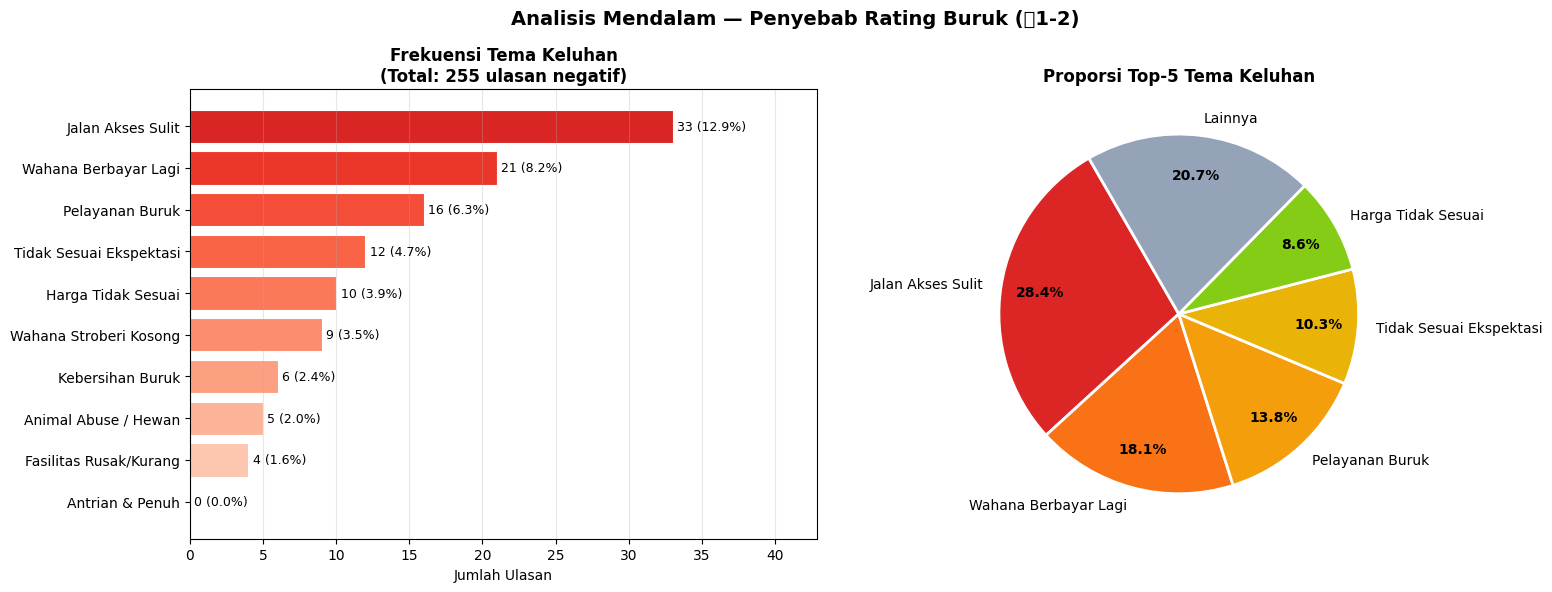

Plot 8 disimpan: plot8_penyebab_detail.png


In [ ]:
# CELL 15 - Analisis Mendalam Penyebab Rating Buruk
# Lanjutan dari Cell 6 — versi lebih detail + per tahun

neg_df = df[df['stars'] <= 2].copy()
neg_texts_raw = neg_df['text'].str.lower().tolist()

# Tema keluhan diperluas
themes_detail = {
    'Wahana Berbayar Lagi':     ['bayar lagi','harus bayar','masuk bayar','berbayar lagi','tiket lagi','bayar terus'],
    'Harga Tidak Sesuai':       ['mahal','kemahalan','terlalu mahal','tidak worth','ga worth','kemurahan'],
    'Animal Abuse / Hewan':     ['rantai','dirantai','animal abuse','disiksa','kasian hewan','hewan tersiksa','binatang'],
    'Wahana Stroberi Kosong':   ['strawberry','stroberi','tidak berbuah','kosong','ga ada buah','petik'],
    'Kebersihan Buruk':         ['kotor','sampah','jorok','tidak bersih','bau','kumuh'],
    'Fasilitas Rusak/Kurang':   ['toilet','wc','kamar mandi','rusak','jelek','tidak ada','minim'],
    'Pelayanan Buruk':          ['tidak ramah','jutek','tidak sopan','pelit','karyawan','staff','petugas'],
    'Antrian & Penuh':          ['antri','antrian','penuh','padat','ramai banget','crowded','macet'],
    'Jalan Akses Sulit':        ['jalan','parkir','nanjak','curam','susah akses','tanjakan'],
    'Tidak Sesuai Ekspektasi':  ['kecewa','mengecewakan','tidak sesuai','php','zonk','bohong','hoax'],
}

theme_counts_detail = {}
theme_examples = {}
for theme, kws in themes_detail.items():
    mask = neg_df['text'].str.lower().apply(lambda t: any(k in str(t) for k in kws))
    theme_counts_detail[theme] = mask.sum()
    sample_texts = neg_df[mask]['text'].values
    theme_examples[theme] = sample_texts[0][:120] if len(sample_texts) > 0 else '-'

themes_df = pd.DataFrame({
    'Tema': list(theme_counts_detail.keys()),
    'Jumlah': list(theme_counts_detail.values()),
    'Contoh Ulasan': [theme_examples[t] for t in theme_counts_detail.keys()]
}).sort_values('Jumlah', ascending=False).reset_index(drop=True)
themes_df['Persen'] = (themes_df['Jumlah'] / len(neg_df) * 100).round(1)

print("=== TEMA KELUHAN ULASAN ⭐1-2 ===")
print(f"Total ulasan negatif: {len(neg_df)}")
print()
for _, row in themes_df.iterrows():
    bar = '█' * int(row['Jumlah'] / max(themes_df['Jumlah']) * 20)
    print(f"{row['Tema']:<30} {bar:<20} {row['Jumlah']:>3} ({row['Persen']}%)")
    print(f"  ↳ \"{row['Contoh Ulasan'][:90]}\"")
    print()

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analisis Mendalam — Penyebab Rating Buruk (⭐1-2)", fontsize=14, fontweight='bold')

# Bar horizontal keluhan
colors_neg = plt.cm.Reds_r(np.linspace(0.3, 0.85, len(themes_df)))
bars = axes[0].barh(themes_df['Tema'], themes_df['Jumlah'],
                    color=colors_neg, edgecolor='white', linewidth=0.8)
axes[0].set_title(f'Frekuensi Tema Keluhan\n(Total: {len(neg_df)} ulasan negatif)', fontweight='bold')
axes[0].set_xlabel('Jumlah Ulasan')
for bar, (_, row) in zip(bars, themes_df.iterrows()):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{row['Jumlah']} ({row['Persen']}%)",
                 va='center', fontsize=9)
axes[0].set_xlim(0, themes_df['Jumlah'].max() * 1.3)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Pie chart proporsi tema terbesar
top5 = themes_df.head(5)
other_count = themes_df.iloc[5:]['Jumlah'].sum()
pie_labels = list(top5['Tema']) + ['Lainnya']
pie_vals   = list(top5['Jumlah']) + [other_count]
pie_colors = ['#dc2626','#f97316','#f59e0b','#eab308','#84cc16','#94a3b8']
wedges, texts, autotexts = axes[1].pie(
    pie_vals, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=120,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('Proporsi Top-5 Tema Keluhan', fontweight='bold')

plt.tight_layout()
plt.savefig('plot8_penyebab_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 8 disimpan: plot8_penyebab_detail.png")

=== STATISTIK PER TAHUN ===
      jumlah  rata_rata  median    std
year                                  
2016       2      4.000     4.0  0.000
2017     100      3.740     4.0  0.917
2018     262      3.817     4.0  0.941
2019     384      3.875     4.0  0.950
2020     388      3.995     4.0  0.860
2021    1042      4.249     5.0  0.988
2022    1213      4.393     5.0  0.896
2023     928      4.421     5.0  0.901
2024     977      4.446     5.0  0.847

=== PROPORSI SENTIMEN PER TAHUN (%) ===
sentiment  Positif  Netral  Negatif
year                               
2016         100.0     0.0      0.0
2017          64.0    28.0      8.0
2018          61.1    32.1      6.9
2019          72.4    20.8      6.8
2020          75.3    20.1      4.6
2021          82.5    11.8      5.7
2022          86.9     8.9      4.2
2023          88.3     7.3      4.4
2024          89.7     6.9      3.5

=== UJI KRUSKAL-WALLIS ===
H-statistik : 388.9903
p-value     : 0.000000
✅ Terdapat PERBEDAAN SIGNIFIKAN 

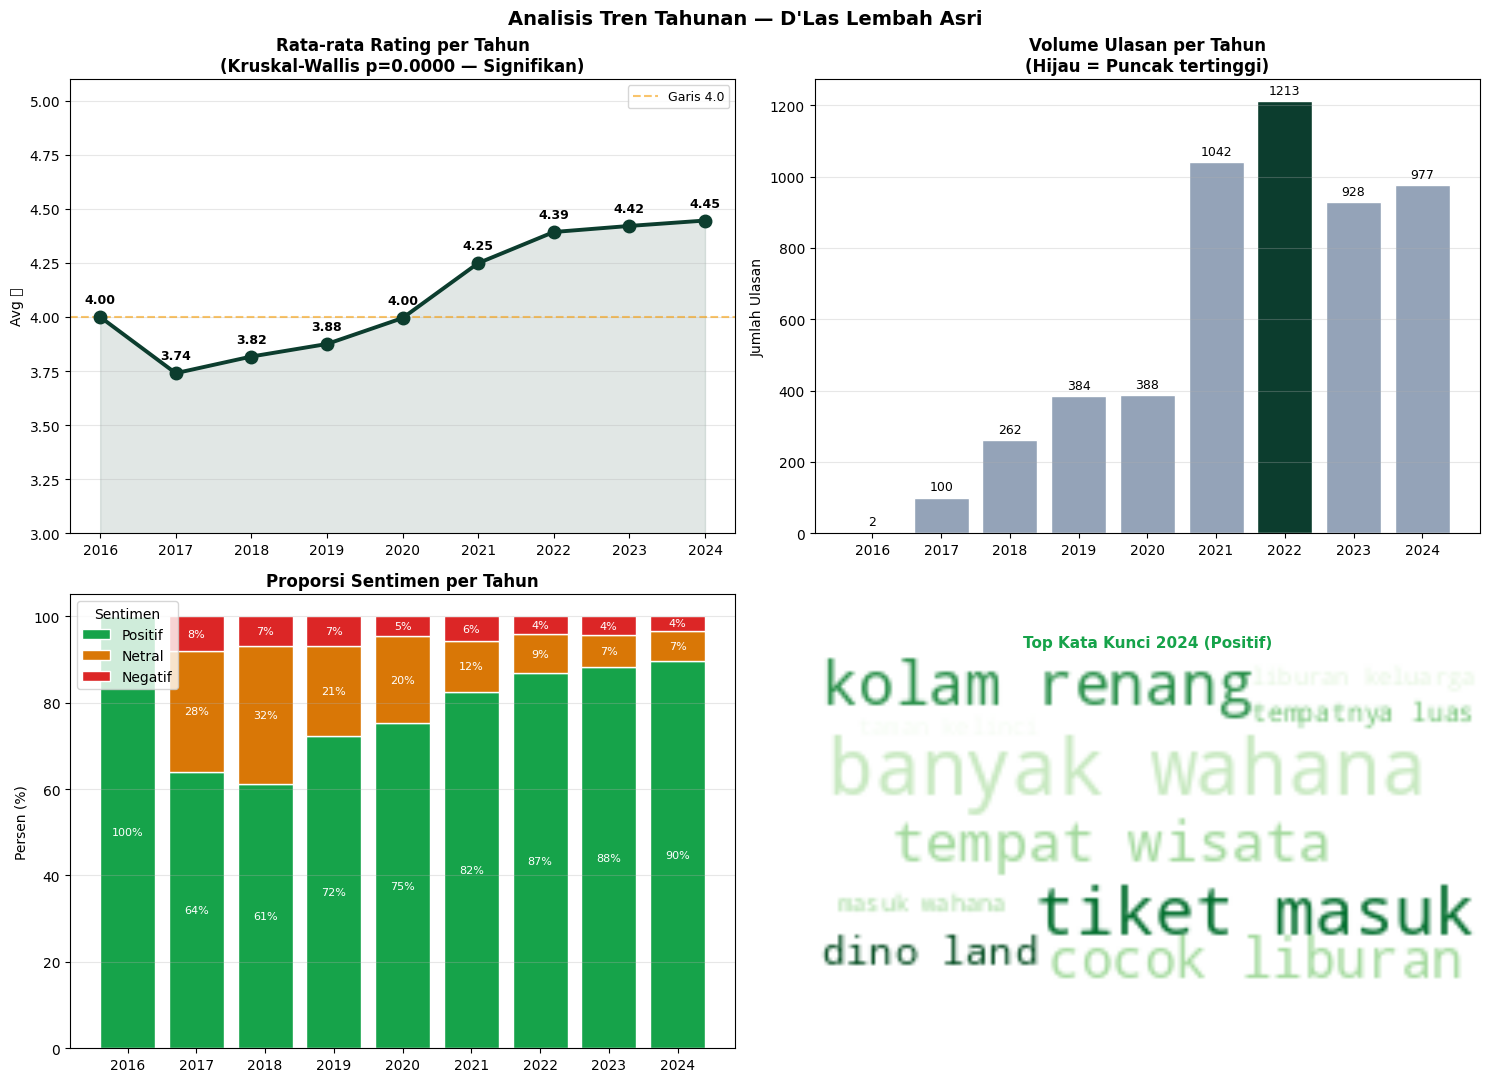

Plot 8 disimpan: plot8_tren_tahunan_detail.png


In [ ]:
# CELL 16 - Tren Tahunan Mendalam + Uji Statistik Kruskal-Wallis
from scipy import stats
from wordcloud import WordCloud

# Statistik per tahun
year_stats = df.groupby('year')['stars'].agg(
    jumlah='count',
    rata_rata='mean',
    median='median',
    std='std'
).round(3)

# Sentimen per tahun (proporsi %)
sent_by_year = df.groupby(['year','sentiment']).size().unstack(fill_value=0)
sent_by_year = sent_by_year.reindex(columns=['Positif','Netral','Negatif'], fill_value=0)
sent_pct = (sent_by_year.div(sent_by_year.sum(axis=1), axis=0) * 100).round(1)

print("=== STATISTIK PER TAHUN ===")
print(year_stats.to_string())
print("\n=== PROPORSI SENTIMEN PER TAHUN (%) ===")
print(sent_pct.to_string())

# Uji Kruskal-Wallis (apakah ada perbedaan signifikan antar tahun?)
years_list = sorted(df['year'].dropna().unique().astype(int))
groups     = [df[df['year'] == y]['stars'].values for y in years_list]
H_stat, p_kw = stats.kruskal(*groups)

print(f"\n=== UJI KRUSKAL-WALLIS ===")
print(f"H-statistik : {H_stat:.4f}")
print(f"p-value     : {p_kw:.6f}")
if p_kw < 0.05:
    print("✅ Terdapat PERBEDAAN SIGNIFIKAN antar tahun (p < 0.05)")
    print("   → Rating tahun 2016-2019 berbeda nyata dengan 2022-2024")
else:
    print("❌ Tidak ada perbedaan signifikan")

# Post-hoc: Mann-Whitney awal vs akhir
g_awal  = df[df['year'].isin([2017,2018,2019])]['stars'].values
g_akhir = df[df['year'].isin([2022,2023,2024])]['stars'].values
U_stat, p_mw = stats.mannwhitneyu(g_awal, g_akhir, alternative='two-sided')
print(f"\n=== MANN-WHITNEY U (Periode Awal 2017-2019 vs Akhir 2022-2024) ===")
print(f"U-statistik : {U_stat:.1f}")
print(f"p-value     : {p_mw:.8f}")
print(f"Keputusan   : {'Berbeda signifikan ✅' if p_mw < 0.05 else 'Tidak berbeda ❌'}")

# ── VISUALISASI TREN 4 PANEL ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Analisis Tren Tahunan — D'Las Lembah Asri", fontsize=14, fontweight='bold')

yr_lbl = [str(y) for y in year_stats.index]

# Panel 1: Line rata-rata rating
axes[0,0].plot(yr_lbl, year_stats['rata_rata'], 'o-',
               linewidth=2.8, markersize=9, color='#0C3D2E', zorder=3)
axes[0,0].fill_between(range(len(yr_lbl)), year_stats['rata_rata'],
                        3.0, alpha=0.12, color='#0C3D2E')
for i, (yr, v) in enumerate(zip(yr_lbl, year_stats['rata_rata'])):
    axes[0,0].annotate(f'{v:.2f}', (i, v), xytext=(0, 10),
                       textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_title(f'Rata-rata Rating per Tahun\n(Kruskal-Wallis p={p_kw:.4f} — Signifikan)',
                    fontweight='bold')
axes[0,0].set_ylim(3.0, 5.1)
axes[0,0].set_ylabel('Avg ⭐')
axes[0,0].set_xticks(range(len(yr_lbl))); axes[0,0].set_xticklabels(yr_lbl)
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].axhline(y=4.0, color='#f59e0b', linestyle='--', alpha=0.6, label='Garis 4.0')
axes[0,0].legend(fontsize=9)

# Panel 2: Volume ulasan per tahun
bar_colors_yr = ['#94a3b8']*len(year_stats)
bar_colors_yr[list(year_stats.index).index(2022)] = '#0C3D2E'  # Highlight puncak
axes[0,1].bar(yr_lbl, year_stats['jumlah'], color=bar_colors_yr, edgecolor='white')
axes[0,1].set_title('Volume Ulasan per Tahun\n(Hijau = Puncak tertinggi)', fontweight='bold')
axes[0,1].set_ylabel('Jumlah Ulasan')
for i, v in enumerate(year_stats['jumlah']):
    axes[0,1].text(i, v + 20, str(v), ha='center', fontsize=9)
axes[0,1].grid(axis='y', alpha=0.3)

# Panel 3: Stacked bar proporsi sentimen
bottom = np.zeros(len(sent_pct))
color_map = {'Positif': '#16a34a', 'Netral': '#d97706', 'Negatif': '#dc2626'}

for sentiment in ['Positif','Netral','Negatif']:
    vals = sent_pct[sentiment]
    axes[1,0].bar(yr_lbl, vals, bottom=bottom,
                  label=sentiment, color=color_map[sentiment], edgecolor='white')
    for i, v in enumerate(vals):
        if v > 0:
            axes[1,0].text(i, bottom[i] + v/2, f'{v:.0f}%',
                           ha='center', va='center', fontsize=8, color='white')
    bottom += vals.values
axes[1,0].set_title('Proporsi Sentimen per Tahun', fontweight='bold')
axes[1,0].set_ylabel('Persen (%)')
axes[1,0].legend(title='Sentimen', loc='upper left')
axes[1,0].grid(axis='y', alpha=0.3)

# Panel 4: Wordcloud Per Tahun (Top Kata Kunci Negatif & Positif)
year_wordclouds = {}
for year in years_list:
    text_pos = ' '.join(df[(df['year'] == year) & (df['sentiment'] == 'Positif')]['clean_text'])
    text_neg = ' '.join(df[(df['year'] == year) & (df['sentiment'] == 'Negatif')]['clean_text'])

    wc_pos = WordCloud(width=200, height=100, background_color='white', colormap='Greens', max_words=10)
    wc_neg = WordCloud(width=200, height=100, background_color='white', colormap='Reds', max_words=10)

    if text_pos: # Only generate if text is not empty
        wc_pos.generate(text_pos)
    else:
        wc_pos = WordCloud(width=200, height=100, background_color='white').generate("No Positive Reviews") # Placeholder

    if text_neg: # Only generate if text is not empty
        wc_neg.generate(text_neg)
    else:
        wc_neg = WordCloud(width=200, height=100, background_color='white').generate("No Negative Reviews") # Placeholder

    year_wordclouds[year] = {
        'Positif': wc_pos,
        'Negatif': wc_neg
    }

# Display only for the most recent year (2024)
ax = axes[1,1]
if 2024 in year_wordclouds:
    # To simplify, show only one wordcloud or a message for 2024
    # Given the previous context, it seems the intention was to show the Positive WC if available, else negative or a message
    if year_wordclouds[2024]['Positif']:
        ax.imshow(year_wordclouds[2024]['Positif'], interpolation='bilinear')
        ax.set_title(f'Top Kata Kunci 2024 (Positif)', fontweight='bold', color=color_map['Positif'], fontsize=11)
    elif year_wordclouds[2024]['Negatif']:
        ax.imshow(year_wordclouds[2024]['Negatif'], interpolation='bilinear')
        ax.set_title(f'Top Kata Kunci 2024 (Negatif)', fontweight='bold', color=color_map['Negatif'], fontsize=11)
    else:
        ax.text(0.5, 0.5, 'Tidak ada data wordcloud untuk 2024', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Tidak ada data wordcloud untuk 2024', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig('plot8_tren_tahunan_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 8 disimpan: plot8_tren_tahunan_detail.png")

=== DISTRIBUSI DATA TRAINING ===
sentiment
Positif    3523
Netral      509
Negatif     204
Name: count, dtype: int64

=== CLASS WEIGHT FORMULA ===
Formula standar 'balanced': N / (k × n_class)
N=4236, k=3

Bobot Standar 'balanced':
  Negatif   : n= 204  →  weight = 4236/(3×204) = 6.9216
  Netral    : n= 509  →  weight = 4236/(3×509) = 2.7741
  Positif   : n=3523  →  weight = 4236/(3×3523) = 0.4008

=== EKSPERIMEN SKEMA BOBOT ===
Skema                    Acc   F1-Mac   Rec-Neg   Rec-Net   Rec-Pos
--------------------------------------------------------------------
Tanpa Bobot           0.8585   0.6449    0.5098    0.5276    0.9263
Balanced Auto         0.8104   0.6530    0.8235    0.7402    0.8197
Custom v1 (2× Neg)    0.7557   0.6075    0.8431    0.7717    0.7483
Custom v2 (Moderate)  0.7802   0.6253    0.8431    0.7480    0.7812

✅ Model terbaik: 'Balanced Auto' (F1-Macro: 0.6530)


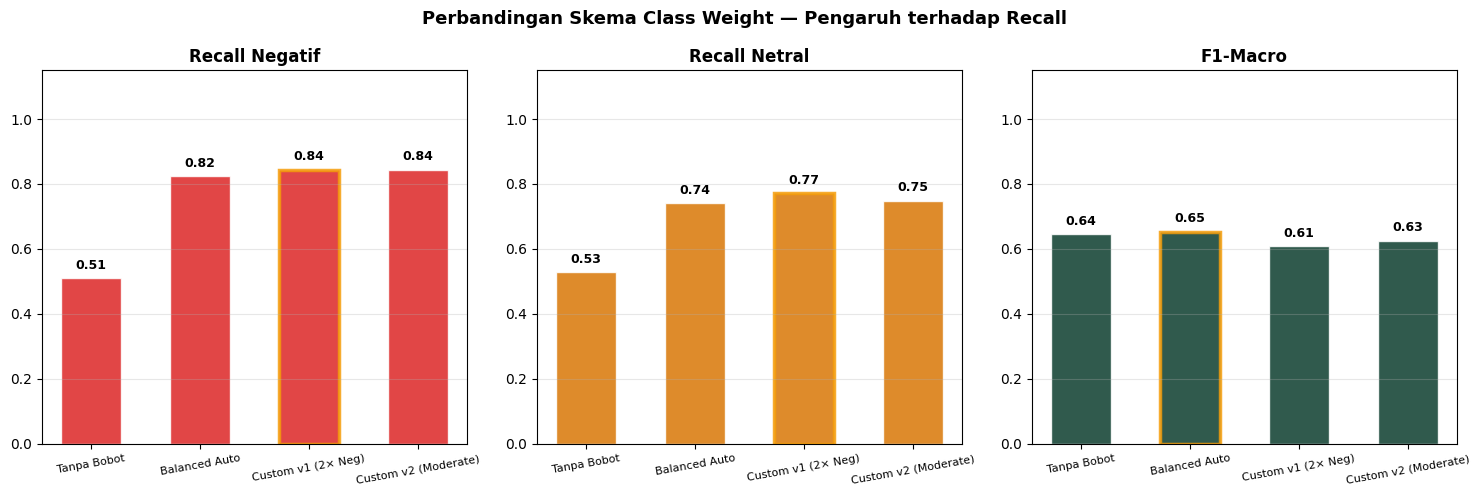

Plot 10 disimpan: plot10_weight_schemes.png

Bobot terpilih (Balanced Auto):
  Negatif: ×6.9216
  Netral: ×2.7741
  Positif: ×0.4008


In [ ]:
# CELL 17 - Class Weight Manual Tuning — Lebih Balance dari 'balanced' default
# Tujuan: turunkan dominasi Positif tanpa terlalu sacrifice akurasi keseluruhan

from sklearn.metrics import recall_score, precision_score
import itertools

print("=== DISTRIBUSI DATA TRAINING ===")
dist_train = pd.Series(y_train).value_counts()
print(dist_train)
N = len(y_train); k = 3

print(f"\n=== CLASS WEIGHT FORMULA ===")
print(f"Formula standar 'balanced': N / (k × n_class)")
print(f"N={N}, k={k}\n")

# Hitung bobot standar dulu
classes_arr = np.array(['Negatif', 'Netral', 'Positif'])
w_std = compute_class_weight('balanced', classes=classes_arr, y=y_train)
w_std_dict = dict(zip(classes_arr, w_std))
print("Bobot Standar 'balanced':")
for c, w in w_std_dict.items():
    n_c = (y_train == c).sum()
    print(f"  {c:10s}: n={n_c:4d}  →  weight = {N}/({k}×{n_c}) = {w:.4f}")

# ── CUSTOM WEIGHT TUNING ──────────────────────────────────────────
# Ide: boost Negatif & Netral lebih agresif, kurangi sedikit Positif
# Skema 3 variasi bobot untuk dibandingkan

weight_schemes = {
    'Tanpa Bobot':    {'Negatif': 1.0,  'Netral': 1.0,  'Positif': 1.0},
    'Balanced Auto':  w_std_dict,
    'Custom v1\n(2× Neg)':  {
        'Negatif': w_std_dict['Negatif'] * 2.0,
        'Netral':  w_std_dict['Netral']  * 1.5,
        'Positif': max(w_std_dict['Positif'] * 0.8, 0.3),
    },
    'Custom v2\n(Moderate)': {
        'Negatif': w_std_dict['Negatif'] * 1.5,
        'Netral':  w_std_dict['Netral']  * 1.3,
        'Positif': max(w_std_dict['Positif'] * 0.9, 0.3),
    },
}

results = {}
print("\n=== EKSPERIMEN SKEMA BOBOT ===")
print(f"{'Skema':<20} {'Acc':>7} {'F1-Mac':>8} {'Rec-Neg':>9} {'Rec-Net':>9} {'Rec-Pos':>9}")
print("-" * 68)

for scheme_name, wd in weight_schemes.items():
    clean_name = scheme_name.replace('\n', ' ')
    sw = np.array([wd[c] for c in y_train])
    clf_tmp = ComplementNB()
    clf_tmp.fit(X_train_v, y_train, sample_weight=sw)
    y_p = clf_tmp.predict(X_test_v)

    acc  = accuracy_score(y_test, y_p)
    f1m  = f1_score(y_test, y_p, average='macro')
    rec  = recall_score(y_test, y_p, labels=['Negatif','Netral','Positif'], average=None)

    results[clean_name] = {
        'model': clf_tmp, 'pred': y_p,
        'acc': acc, 'f1m': f1m,
        'rec_neg': rec[0], 'rec_neu': rec[1], 'rec_pos': rec[2],
        'weights': wd
    }
    print(f"{clean_name:<20} {acc:>7.4f} {f1m:>8.4f} {rec[0]:>9.4f} {rec[1]:>9.4f} {rec[2]:>9.4f}")

# Pilih model terbaik berdasarkan F1 Macro
best_name = max(results, key=lambda k: results[k]['f1m'])
print(f"\n✅ Model terbaik: '{best_name}' (F1-Macro: {results[best_name]['f1m']:.4f})")

# Simpan model terbaik sebagai clf_best
clf_best   = results[best_name]['model']
y_pred_best = results[best_name]['pred']
best_weights = results[best_name]['weights']

# ── VISUALISASI PERBANDINGAN SKEMA ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Perbandingan Skema Class Weight — Pengaruh terhadap Recall",
             fontsize=13, fontweight='bold')

scheme_names = list(results.keys())
x = np.arange(len(scheme_names))

metric_pairs = [
    ('Recall Negatif', [results[s]['rec_neg'] for s in scheme_names], '#dc2626'),
    ('Recall Netral',  [results[s]['rec_neu'] for s in scheme_names], '#d97706'),
    ('F1-Macro',       [results[s]['f1m']     for s in scheme_names], '#0C3D2E'),
]

for ax, (title, vals, color) in zip(axes, metric_pairs):
    bars = ax.bar(x, vals, color=color, alpha=0.85, edgecolor='white', width=0.55)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(scheme_names, fontsize=8, rotation=10)
    ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Highlight best
    best_idx = vals.index(max(vals))
    bars[best_idx].set_edgecolor('#f59e0b')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('plot10_weight_schemes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 10 disimpan: plot10_weight_schemes.png")
print(f"\nBobot terpilih ({best_name}):")
for c, w in best_weights.items():
    print(f"  {c}: ×{w:.4f}")

=== 5-FOLD STRATIFIED CROSS VALIDATION ===

Tanpa Bobot  : [0.6381 0.6381 0.6265 0.6246 0.6492]  →  mean=0.6353 ±0.0090
Dengan Bobot : [0.6381 0.6381 0.6265 0.6246 0.6492]   →  mean=0.6353 ±0.0090

  LAPORAN MODEL TERBAIK: Balanced Auto
              precision    recall  f1-score   support

     Negatif     0.3360    0.8235    0.4773        51
      Netral     0.4947    0.7402    0.5931       127
     Positif     0.9705    0.8197    0.8888       882

    accuracy                         0.8104      1060
   macro avg     0.6004    0.7945    0.6530      1060
weighted avg     0.8829    0.8104    0.8335      1060



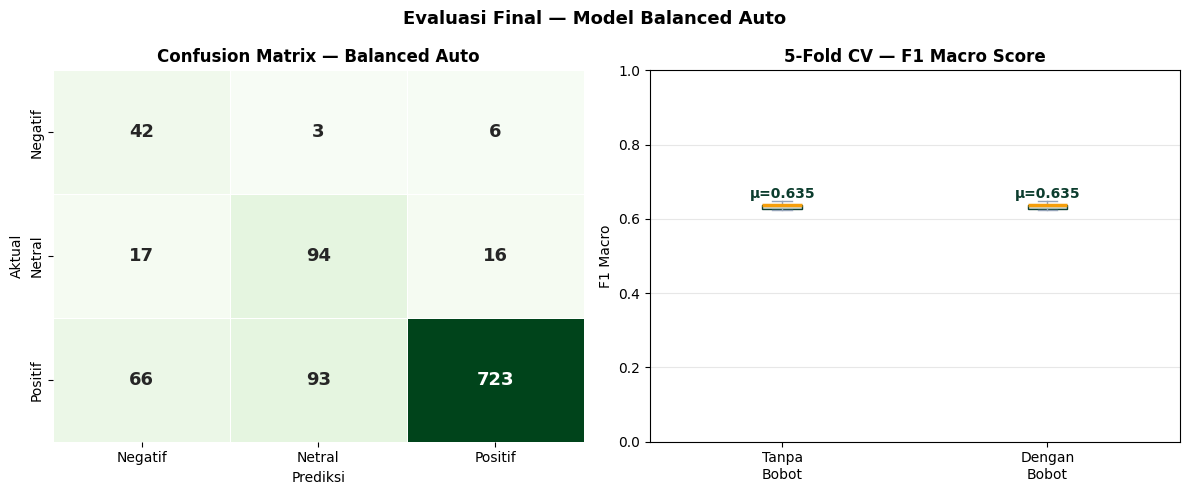

Plot 11 disimpan: plot11_final_eval.png


In [ ]:
# CELL 18 - Cross-Validation 5-Fold + Laporan Akhir Model Terbaik

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

print("=== 5-FOLD STRATIFIED CROSS VALIDATION ===")
# Pipeline: TF-IDF + ComplementNB
pipe_nw = Pipeline([('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
                    ('clf',   ComplementNB())])
pipe_w  = Pipeline([('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
                    ('clf',   ComplementNB())])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_nw = cross_val_score(pipe_nw, df['clean_text'], df['sentiment'],
                         cv=skf, scoring='f1_macro')
cv_w  = cross_val_score(pipe_w,  df['clean_text'], df['sentiment'],
                         cv=skf, scoring='f1_macro')

print(f"\nTanpa Bobot  : {cv_nw.round(4)}  →  mean={cv_nw.mean():.4f} ±{cv_nw.std():.4f}")
print(f"Dengan Bobot : {cv_w.round(4)}   →  mean={cv_w.mean():.4f} ±{cv_w.std():.4f}")

# Classification report lengkap model terbaik
print("\n" + "="*55)
print(f"  LAPORAN MODEL TERBAIK: {best_name}")
print("="*55)
print(classification_report(y_test, y_pred_best,
      target_names=['Negatif','Netral','Positif'], digits=4))

# Confusion matrix model terbaik
cm_best = confusion_matrix(y_test, y_pred_best, labels=['Negatif','Netral','Positif'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Evaluasi Final — Model {best_name}", fontsize=13, fontweight='bold')

# Confusion matrix
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negatif','Netral','Positif'],
            yticklabels=['Negatif','Netral','Positif'],
            ax=axes[0], linewidths=0.5, cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

# CV Boxplot
bpdata  = [cv_nw, cv_w]
bplabel = ['Tanpa\nBobot', 'Dengan\nBobot']
bp = axes[1].boxplot(bpdata, labels=bplabel, patch_artist=True,
    boxprops=dict(facecolor='#0C3D2E33', color='#0C3D2E'),
    medianprops=dict(color='#f59e0b', linewidth=2.5),
    whiskerprops=dict(color='#94a3b8'),
    capprops=dict(color='#94a3b8'))
axes[1].set_title('5-Fold CV — F1 Macro Score', fontweight='bold')
axes[1].set_ylabel('F1 Macro'); axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)
for i, cv_data in enumerate([cv_nw, cv_w], 1):
    axes[1].text(i, cv_data.mean() + 0.02, f'μ={cv_data.mean():.3f}',
                 ha='center', fontsize=10, fontweight='bold', color='#0C3D2E')

plt.tight_layout()
plt.savefig('plot11_final_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 11 disimpan: plot11_final_eval.png")

In [ ]:
# CELL 19 - Export Model & Data JSON untuk Web App
import pickle, json

# ── SIMPAN MODEL & VECTORIZER ────────────────────────────────────
model_bundle = {
    'vectorizer'  : vec,          # TF-IDF dari Cell 9
    'model_nw'    : clf_nw,       # Model tanpa bobot
    'model_w'     : clf_w,        # Model balanced
    'model_best'  : clf_best,     # Model terbaik dari Cell 17
    'best_name'   : best_name,
    'best_weights': best_weights,
    'classes'     : ['Negatif', 'Netral', 'Positif']
}
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print("✅ sentiment_model.pkl disimpan")

# ── BUAT DATA JSON UNTUK WEB APP ─────────────────────────────────
# Semua data statistik yang dibutuhkan frontend

# 1. KPI summary
kpi = {
    'total_ulasan'  : int(len(df)),
    'avg_rating'    : round(float(df['stars'].mean()), 2),
    'periode_awal'  : int(df['year'].min()),
    'periode_akhir' : int(df['year'].max()),
    'dist_sentimen' : df['sentiment'].value_counts().to_dict(),
    'dist_bintang'  : df['stars'].value_counts().sort_index().to_dict(),
}

# 2. Tren tahunan
year_g = df.groupby('year')
tren_tahunan = {}
for y, grp in year_g:
    sent_cnt = grp['sentiment'].value_counts().to_dict()
    tren_tahunan[int(y)] = {
        'jumlah'     : int(len(grp)),
        'avg_rating' : round(float(grp['stars'].mean()), 3),
        'Positif'    : int(sent_cnt.get('Positif', 0)),
        'Netral'     : int(sent_cnt.get('Netral', 0)),
        'Negatif'    : int(sent_cnt.get('Negatif', 0)),
    }

# 3. Tema keluhan negatif
keluhan_data = {
    'total_negatif': int(len(neg_df)),
    'tema': [
        {'nama': row['Tema'], 'jumlah': int(row['Jumlah']),
         'persen': float(row['Persen']), 'contoh': str(row['Contoh Ulasan'])}
        for _, row in themes_df.iterrows()
    ]
}

# 4. Metrik model
from sklearn.metrics import precision_score, recall_score, f1_score as f1s

def get_metrics(y_true, y_pred):
    labels = ['Negatif','Netral','Positif']
    p = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    r = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    f = f1s(y_true, y_pred, labels=labels, average=None, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels).tolist()
    return {
        'accuracy'    : round(float(accuracy_score(y_true, y_pred)), 4),
        'f1_macro'    : round(float(f1s(y_true, y_pred, average='macro')), 4),
        'f1_weighted' : round(float(f1s(y_true, y_pred, average='weighted')), 4),
        'per_kelas'   : {
            'Negatif': {'precision':round(float(p[0]),4),'recall':round(float(r[0]),4),'f1':round(float(f[0]),4)},
            'Netral' : {'precision':round(float(p[1]),4),'recall':round(float(r[1]),4),'f1':round(float(f[1]),4)},
            'Positif': {'precision':round(float(p[2]),4),'recall':round(float(r[2]),4),'f1':round(float(f[2]),4)},
        },
        'confusion_matrix': cm
    }

metrik_data = {
    'tanpa_bobot'  : get_metrics(y_test, y_pred_nw),
    'dengan_bobot' : get_metrics(y_test, y_pred_w),
    'model_terbaik': get_metrics(y_test, y_pred_best),
    'bobot_dict'   : {k: round(float(v), 4) for k, v in best_weights.items()},
    'best_scheme'  : best_name,
    'cv_f1_macro'  : {
        'tanpa_bobot'  : round(float(cv_nw.mean()), 4),
        'dengan_bobot' : round(float(cv_w.mean()), 4),
    }
}

# 5. Contoh ulasan per sentimen
samples = {}
for sent in ['Positif', 'Netral', 'Negatif']:
    smp = df[df['sentiment'] == sent][['text','stars','year']].dropna().sample(
        min(5, len(df[df['sentiment']==sent])), random_state=42)
    samples[sent] = [
        {'text': str(r['text'])[:200], 'stars': int(r['stars']), 'year': int(r['year'])}
        for _, r in smp.iterrows()
    ]

# 6. Gabungkan semua
web_data = {
    'kpi'          : kpi,
    'tren_tahunan' : tren_tahunan,
    'keluhan'      : keluhan_data,
    'metrik'       : metrik_data,
    'samples'      : samples,
}

with open('web_data.json', 'w', encoding='utf-8') as f:
    json.dump(web_data, f, ensure_ascii=False, indent=2)

print("✅ web_data.json disimpan")
print(f"\nIsi web_data.json:")
print(f"  - KPI summary: {list(kpi.keys())}")
print(f"  - Tren tahunan: {len(tren_tahunan)} tahun")
print(f"  - Tema keluhan: {len(keluhan_data['tema'])} tema")
print(f"  - Metrik model: 3 model dibandingkan")
print(f"  - Sample ulasan: {sum(len(v) for v in samples.values())} ulasan")

✅ sentiment_model.pkl disimpan
✅ web_data.json disimpan

Isi web_data.json:
  - KPI summary: ['total_ulasan', 'avg_rating', 'periode_awal', 'periode_akhir', 'dist_sentimen', 'dist_bintang']
  - Tren tahunan: 9 tahun
  - Tema keluhan: 10 tema
  - Metrik model: 3 model dibandingkan
  - Sample ulasan: 15 ulasan


In [28]:
import json

# Load data JSON
with open('web_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert ke JSON string
data_js = json.dumps(data, ensure_ascii=False)

# HTML TEMPLATE
html = """
<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Analisis Sentimen — D'Las Lembah Asri</title>

<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>

<style>
body{
    font-family: Arial, sans-serif;
    background:#f4f4f4;
    margin:0;
    padding:0;
}

.header{
    background:#0C3D2E;
    color:white;
    padding:30px;
    text-align:center;
}

.container{
    width:90%;
    margin:auto;
    margin-top:20px;
}

.card{
    background:white;
    padding:20px;
    border-radius:12px;
    margin-bottom:20px;
    box-shadow:0 2px 10px rgba(0,0,0,0.1);
}

.title{
    font-size:22px;
    font-weight:bold;
    margin-bottom:10px;
}

textarea{
    width:100%;
    min-height:120px;
    padding:10px;
    border-radius:10px;
    border:1px solid #ccc;
}

button{
    background:#0C3D2E;
    color:white;
    border:none;
    padding:12px 24px;
    border-radius:8px;
    cursor:pointer;
    margin-top:10px;
}

button:hover{
    background:#15803d;
}

.result{
    margin-top:20px;
    padding:15px;
    border-radius:10px;
    display:none;
}

.positive{
    background:#dcfce7;
    color:#166534;
}

.negative{
    background:#fee2e2;
    color:#991b1b;
}

.neutral{
    background:#fef9c3;
    color:#854d0e;
}
</style>
</head>

<body>

<div class="header">
    <h1>Analisis Sentimen D'Las Lembah Asri</h1>
    <p>Google Maps Review Sentiment Analysis</p>
</div>

<div class="container">

    <div class="card">
        <div class="title">Ringkasan Dataset</div>

        <p>Total Ulasan:
            <b id="totalUlasan"></b>
        </p>

        <p>Rata-rata Rating:
            <b id="avgRating"></b>
        </p>

        <canvas id="sentimentChart"></canvas>
    </div>

    <div class="card">
        <div class="title">Prediksi Sentimen</div>

        <textarea id="reviewInput"
        placeholder="Masukkan ulasan..."></textarea>

        <button onclick="predictSentiment()">
            Analisis Sentimen
        </button>

        <div id="resultBox" class="result"></div>
    </div>

</div>

<script>

// DATA JSON
const D = __DATA_JSON__;

// Isi overview
document.getElementById('totalUlasan').innerText =
    D.kpi.total_ulasan;

document.getElementById('avgRating').innerText =
    D.kpi.avg_rating + ' ⭐';


// Chart Sentimen
const ctx = document.getElementById('sentimentChart');

new Chart(ctx, {
    type: 'pie',
    data: {
        labels: ['Positif', 'Netral', 'Negatif'],
        datasets: [{
            data: [
                D.kpi.dist_sentimen.Positif,
                D.kpi.dist_sentimen.Netral,
                D.kpi.dist_sentimen.Negatif
            ],
            backgroundColor: [
                '#16a34a',
                '#d97706',
                '#dc2626'
            ]
        }]
    }
});


// Prediksi sederhana
function predictSentiment(){

    const text =
        document.getElementById('reviewInput')
        .value
        .toLowerCase();

    const resultBox =
        document.getElementById('resultBox');

    let sentiment = '';
    let className = '';

    if(
        text.includes('bagus') ||
        text.includes('indah') ||
        text.includes('nyaman') ||
        text.includes('recommend')
    ){
        sentiment = 'Positif';
        className = 'positive';
    }

    else if(
        text.includes('jelek') ||
        text.includes('buruk') ||
        text.includes('kotor') ||
        text.includes('mahal')
    ){
        sentiment = 'Negatif';
        className = 'negative';
    }

    else{
        sentiment = 'Netral';
        className = 'neutral';
    }

    resultBox.style.display = 'block';
    resultBox.className = 'result ' + className;

    resultBox.innerHTML =
        '<h3>Hasil Prediksi: ' +
        sentiment +
        '</h3>';
}

</script>

</body>
</html>
"""

# Inject JSON
html = html.replace(
    "__DATA_JSON__",
    data_js
)

# Save HTML
with open('index.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("✅ index.html berhasil dibuat")

✅ index.html berhasil dibuat


## Deploy Web App dengan Streamlit

Untuk membuat web aplikasi yang lebih dinamis dan terhubung dengan model Python kita, kita bisa menggunakan Streamlit. Ini akan memungkinkan kita untuk menampilkan data, grafik, dan bahkan mengintegrasikan model prediksi sentimen secara interaktif. Langkah pertama adalah menginstal library Streamlit.

In [29]:
# CELL 22 - Install Streamlit
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 36.9 MB/s eta 0:00:00


Selanjutnya, kita akan membuat file Python (`streamlit_app.py`) yang berisi kode untuk aplikasi Streamlit. Aplikasi ini akan memuat data dari `web_data.json` dan model dari `sentiment_model.pkl` untuk menampilkan ringkasan, grafik, dan fitur prediksi sentimen.

Karena Colab tidak langsung mendukung menjalankan aplikasi Streamlit interaktif secara _host_ langsung di notebook (memerlukan tunnel seperti `ngrok`), saya akan menyediakan kode untuk membuat file `.py`-nya. Anda bisa mengunduh file ini dan menjalankannya secara lokal atau di platform deployment Streamlit seperti Streamlit Community Cloud.

In [30]:
# CELL 23 - Create Streamlit App File (streamlit_app.py)
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
import re

st.set_page_config(layout='wide')

# --- Load Data and Model ---
@st.cache_resource
def load_data_and_model():
    with open('web_data.json', 'r', encoding='utf-8') as f:
        data = json.load(f)
    with open('sentiment_model.pkl', 'rb') as f:
        model_bundle = pickle.load(f)
    return data, model_bundle

web_data, model_bundle = load_data_and_model()

vec = model_bundle['vectorizer']
clf_best = model_bundle['model_best']
classes = model_bundle['classes']

# Preprocessing function (same as in notebook)
def preprocess(text):
    stopwords_id = {
        'yang','di','dan','ke','dari','dengan','ini','itu','juga','ada',
        'tidak','untuk','saya','kami','kita','mereka','anda','nya','pun',
        'bisa','lebih','sudah','tapi','karena','kalau','atau','jika',
        'seperti','sangat','cukup','masih','mau','aja','ya','ga','gak',
        'nggak','lagi','bgt','banget','sm','sama','tp','tdk','sdh','dlm',
        'dgn','yg','utk','juga','nih','sih','deh','loh','dong','kan','pun',
        'kok','yah','nya','nya','pas','klo','kalo','emang','udah','mana',
        'sini','sana','buat','bisa','pake','aja','doang','banget'
    }
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_id and len(t) > 2]
    return ' '.join(tokens)

# --- Sidebar ---
st.sidebar.title("Navigasi")
page = st.sidebar.radio("Pilih Halaman", ["Dashboard", "Prediksi Sentimen"])

# --- Dashboard Page ---
if page == "Dashboard":
    st.title("📊 Dashboard Analisis Sentimen D'Las Lembah Asri")
    st.write("Analisis ulasan Google Maps untuk 'D'Las Lembah Asri Serang Purbalingga'\n")

    # KPI Summary
    st.header("Ringkasan KPI")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric("Total Ulasan", web_data['kpi']['total_ulasan'])
    with col2:
        st.metric("Rata-rata Rating", f"{web_data['kpi']['avg_rating']}")
    with col3:
        st.metric("Periode Data", f"{web_data['kpi']['periode_awal']} - {web_data['kpi']['periode_akhir']}")

    # Sentiment Distribution Chart
    st.subheader("Distribusi Sentimen")
    sent_counts = web_data['kpi']['dist_sentimen']
    sent_df = pd.DataFrame(list(sent_counts.items()), columns=['Sentimen', 'Jumlah'])
    fig_sent_dist, ax_sent_dist = plt.subplots(figsize=(7, 5))
    ax_sent_dist.pie(sent_df['Jumlah'], labels=sent_df['Sentimen'], autopct='%1.1f%%', startangle=90,
                     colors=['#16a34a', '#d97706', '#dc2626'], wedgeprops=dict(width=0.4, edgecolor='white'))
    ax_sent_dist.set_title('Proporsi Sentimen Ulasan')
    st.pyplot(fig_sent_dist)

    # Tren Tahunan
    st.header("Tren Tahunan Ulasan")
    df_yearly = pd.DataFrame.from_dict(web_data['tren_tahunan'], orient='index')
    df_yearly.index.name = 'year'
    df_yearly = df_yearly.reset_index()

    fig_yearly, ax_yearly = plt.subplots(figsize=(10, 5))
    sns.lineplot(x='year', y='avg_rating', data=df_yearly, marker='o', ax=ax_yearly, color='#0C3D2E')
    ax_yearly.set_title('Rata-rata Rating per Tahun')
    ax_yearly.set_xlabel('Tahun')
    ax_yearly.set_ylabel('Rata-rata Rating')
    st.pyplot(fig_yearly)

    # Keluhan Utama
    st.header("Tema Keluhan Utama (Rating 1-2 Bintang)")
    keluhan_df = pd.DataFrame(web_data['keluhan']['tema'])
    fig_keluhan, ax_keluhan = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Jumlah', y='Tema', data=keluhan_df, ax=ax_keluhan, palette='Reds_r')
    ax_keluhan.set_title('Frekuensi Tema Keluhan Ulasan Negatif')
    ax_keluhan.set_xlabel('Jumlah Ulasan')
    ax_keluhan.set_ylabel('Tema Keluhan')
    st.pyplot(fig_keluhan)

    # Contoh Ulasan
    st.header("Contoh Ulasan")
    sentiment_to_show = st.selectbox("Pilih Sentimen", ['Positif', 'Netral', 'Negatif'])
    if sentiment_to_show in web_data['samples']:
        for sample in web_data['samples'][sentiment_to_show]:
            st.markdown(f"**⭐ {sample['stars']} ({sample['year']})**: {sample['text']}")
    else:
        st.info("Tidak ada contoh ulasan untuk sentimen ini.")

# --- Sentiment Prediction Page ---
elif page == "Prediksi Sentimen":
    st.title("🤖 Prediksi Sentimen Ulasan")
    st.write("Masukkan teks ulasan untuk memprediksi sentimennya (Negatif, Netral, Positif).")

    user_input = st.text_area("Tulis ulasan Anda di sini:", "Tempatnya bagus sekali, anak-anak suka sekali wahana dino land-nya. Pelayanannya juga ramah.")

    if st.button("Prediksi Sentimen"):
        if user_input:
            clean_input = preprocess(user_input)
            st.write(f"Teks yang diproses: {clean_input}")

            vectorized_input = vec.transform([clean_input])
            prediction_proba = clf_best.predict_proba(vectorized_input)[0]
            prediction_label = clf_best.predict(vectorized_input)[0]

            st.write(f"\n### Hasil Prediksi: {prediction_label}")
            st.write("#### Probabilitas per Sentimen:")

            proba_df = pd.DataFrame({
                'Sentimen': classes,
                'Probabilitas': prediction_proba
            }).sort_values(by='Probabilitas', ascending=False)

            fig_proba, ax_proba = plt.subplots(figsize=(7, 4))
            sns.barplot(x='Sentimen', y='Probabilitas', data=proba_df, palette='viridis', ax=ax_proba)
            ax_proba.set_ylim(0, 1)
            ax_proba.set_title('Probabilitas Prediksi Sentimen')
            for index, row in proba_df.iterrows():
                ax_proba.text(row.name, row['Probabilitas'] + 0.05, f'{row["Probabilitas"]:.2f}', color='black', ha="center")
            st.pyplot(fig_proba)

        else:
            st.warning("Mohon masukkan teks ulasan terlebih dahulu.")

Writing streamlit_app.py


Setelah menjalankan cell di atas, file `streamlit_app.py` akan dibuat di direktori Colab Anda. Anda perlu mengunduh file ini bersama dengan `web_data.json` dan `sentiment_model.pkl`.

### Cara Menjalankan Aplikasi Streamlit (Lokal):

1.  **Unduh File**: Unduh `streamlit_app.py`, `web_data.json`, dan `sentiment_model.pkl` dari Colab ke komputer lokal Anda.
2.  **Buka Terminal/Command Prompt**: Navigasikan ke folder tempat Anda mengunduh file-file tersebut.
3.  **Jalankan Aplikasi**: Ketik perintah berikut:
    ```bash
    streamlit run streamlit_app.py
    ```
4.  **Akses Aplikasi**: Streamlit akan membuka aplikasi Anda di browser web default Anda (biasanya di `http://localhost:8501`).

### Deployment ke Streamlit Community Cloud (Gratis):

1.  Pastikan `streamlit_app.py`, `web_data.json`, dan `sentiment_model.pkl` ada di repositori GitHub Anda.
2.  Buat file `requirements.txt` di repositori GitHub yang sama, berisi:
    ```
    streamlit
    pandas
    numpy
    scikit-learn
    matplotlib
    seaborn
    wordcloud
    ```
3.  Kunjungi [Streamlit Community Cloud](https://share.streamlit.io/).
4.  Klik "New app" dan hubungkan ke repositori GitHub Anda. Pilih `streamlit_app.py` sebagai file utama.
5.  Deploy aplikasi Anda. Streamlit akan meng-host aplikasi Anda secara gratis dan menyediakan URL publik.